## This is how Bagging/RandomForest works Internally By Using Feature Sampling

### Importing Libraries

In [41]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

#### Generating a Synthetic Classification Dataset

In [42]:
X , y = make_classification(n_features=5, n_informative=5, n_redundant=0, n_clusters_per_class=1)

In [43]:
df = pd.DataFrame(X , columns=['col1', 'col2' , 'col3', 'col4', 'col5'])
df['target'] = y

In [44]:
df.shape

(100, 6)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col1    100 non-null    float64
 1   col2    100 non-null    float64
 2   col3    100 non-null    float64
 3   col4    100 non-null    float64
 4   col5    100 non-null    float64
 5   target  100 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 4.8 KB


In [46]:
df.head()

,col1,col2,col3,col4,col5,target
0,2.143321,-1.134186,0.309366,2.814881,3.156646,0
1,-1.174667,0.819698,1.310935,-0.680765,1.407899,1
2,0.022491,0.097720,1.756615,0.434720,-0.389601,0
3,0.121667,-2.468865,0.701890,-0.710501,-1.443270,0
4,-1.354646,0.544662,1.335414,-0.844138,1.544361,1


### Function for features/columns Sampling

In [47]:
def sample_features(df,percent):
    cols = random.sample(df.columns.tolist()[:-1], int(percent*(df.shape[1]-1)))
    new_df = df[cols]
    new_df['target'] = df['target']
    return new_df

### Using Feature sampling

#### `RandomForest` is collection of decision tree 
Now we will Create 3 new datasets using Feature Sampling With Replacement

In [48]:
df1 = sample_features(df,0.8)
df1

C:\Users\hb292\AppData\Local\Temp\ipykernel_22948\1964868790.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col4,col3,col1,col5,target
0,2.814881,0.309366,2.143321,3.156646,0
1,-0.680765,1.310935,-1.174667,1.407899,1
2,0.434720,1.756615,0.022491,-0.389601,0
3,-0.710501,0.701890,0.121667,-1.443270,0
4,-0.844138,1.335414,-1.354646,1.544361,1
...,...,...,...,...,...
95,-0.565075,2.517309,-1.377033,1.064426,1
96,4.346683,-0.608021,2.460156,3.271832,0
97,-0.684878,0.833369,-0.546430,0.205803,1
98,-1.490755,3.236350,-2.554952,1.725424,1


In [49]:
df2 = sample_features(df,0.8)
df2

C:\Users\hb292\AppData\Local\Temp\ipykernel_22948\1964868790.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col3,col2,col1,col4,target
0,0.309366,-1.134186,2.143321,2.814881,0
1,1.310935,0.819698,-1.174667,-0.680765,1
2,1.756615,0.097720,0.022491,0.434720,0
3,0.701890,-2.468865,0.121667,-0.710501,0
4,1.335414,0.544662,-1.354646,-0.844138,1
...,...,...,...,...,...
95,2.517309,2.178043,-1.377033,-0.565075,1
96,-0.608021,-3.515363,2.460156,4.346683,0
97,0.833369,1.403799,-0.546430,-0.684878,1
98,3.236350,2.511431,-2.554952,-1.490755,1


In [50]:
df3 = sample_features(df,0.8)
df3

C:\Users\hb292\AppData\Local\Temp\ipykernel_22948\1964868790.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['target'] = df['target']


,col2,col3,col1,col5,target
0,-1.134186,0.309366,2.143321,3.156646,0
1,0.819698,1.310935,-1.174667,1.407899,1
2,0.097720,1.756615,0.022491,-0.389601,0
3,-2.468865,0.701890,0.121667,-1.443270,0
4,0.544662,1.335414,-1.354646,1.544361,1
...,...,...,...,...,...
95,2.178043,2.517309,-1.377033,1.064426,1
96,-3.515363,-0.608021,2.460156,3.271832,0
97,1.403799,0.833369,-0.546430,0.205803,1
98,2.511431,3.236350,-2.554952,1.725424,1


In [51]:
print(f"""    {df1.columns},
      {df2.columns},
      {df3.columns}""")

    Index(['col4', 'col3', 'col1', 'col5', 'target'], dtype='object'),
      Index(['col3', 'col2', 'col1', 'col4', 'target'], dtype='object'),
      Index(['col2', 'col3', 'col1', 'col5', 'target'], dtype='object')


#### calling decisiontreeClassifier and making objects for my 3 datasets 

In [52]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [53]:
clf1.fit(df1.iloc[:,0:4],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:4],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:4],df3.iloc[:,-1])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


#### ploting 3 decision tree by row sampling

In [54]:
from sklearn.tree import plot_tree

[Text(0.6, 0.9285714285714286, 'x[2] <= -0.095\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.3333333333333333, 0.7857142857142857, 'x[3] <= -0.623\ngini = 0.286\nsamples = 52\nvalue = [9, 43]'),
 Text(0.4666666666666667, 0.8571428571428572, 'True  '),
 Text(0.13333333333333333, 0.6428571428571429, 'x[2] <= -1.143\ngini = 0.49\nsamples = 14\nvalue = [8, 6]'),
 Text(0.06666666666666667, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [0, 5]'),
 Text(0.2, 0.5, 'x[3] <= -1.02\ngini = 0.198\nsamples = 9\nvalue = [8, 1]'),
 Text(0.13333333333333333, 0.35714285714285715, 'gini = 0.0\nsamples = 6\nvalue = [6, 0]'),
 Text(0.26666666666666666, 0.35714285714285715, 'x[3] <= -0.788\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.2, 0.21428571428571427, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.3333333333333333, 0.21428571428571427, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.5333333333333333, 0.6428571428571429, 'x[3] <= 0.145\ngini = 0.051\nsamples = 38\nvalue = [1, 37]')

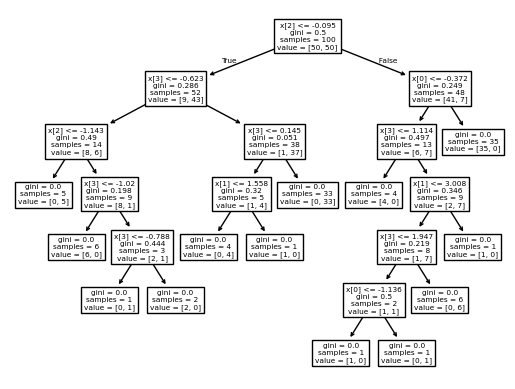

In [55]:
plot_tree(clf1)

[Text(0.4861111111111111, 0.9166666666666666, 'x[2] <= -0.095\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.2222222222222222, 0.75, 'x[1] <= -1.189\ngini = 0.286\nsamples = 52\nvalue = [9, 43]'),
 Text(0.35416666666666663, 0.8333333333333333, 'True  '),
 Text(0.1111111111111111, 0.5833333333333334, 'x[2] <= -1.602\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.05555555555555555, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.16666666666666666, 0.4166666666666667, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.3333333333333333, 0.5833333333333334, 'x[3] <= 1.383\ngini = 0.087\nsamples = 44\nvalue = [2, 42]'),
 Text(0.2777777777777778, 0.4166666666666667, 'x[1] <= -0.028\ngini = 0.045\nsamples = 43\nvalue = [1, 42]'),
 Text(0.2222222222222222, 0.25, 'x[0] <= 1.338\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.16666666666666666, 0.08333333333333333, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]'),
 Text(0.2777777777777778, 0.08333333333333

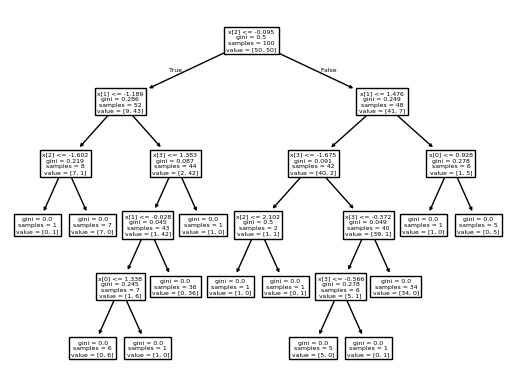

In [56]:
plot_tree(clf2)

[Text(0.5, 0.9166666666666666, 'x[2] <= -0.095\ngini = 0.5\nsamples = 100\nvalue = [50, 50]'),
 Text(0.25, 0.75, 'x[0] <= -1.189\ngini = 0.286\nsamples = 52\nvalue = [9, 43]'),
 Text(0.375, 0.8333333333333333, 'True  '),
 Text(0.125, 0.5833333333333334, 'x[3] <= 0.167\ngini = 0.219\nsamples = 8\nvalue = [7, 1]'),
 Text(0.0625, 0.4166666666666667, 'gini = 0.0\nsamples = 7\nvalue = [7, 0]'),
 Text(0.1875, 0.4166666666666667, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.375, 0.5833333333333334, 'x[3] <= -1.198\ngini = 0.087\nsamples = 44\nvalue = [2, 42]'),
 Text(0.3125, 0.4166666666666667, 'x[1] <= 0.597\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.375, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.4375, 0.4166666666666667, 'gini = 0.0\nsamples = 39\nvalue = [0, 39]'),
 Text(0.75, 0.75, 'x[0] <= 1.476\ngini = 0.249\nsamples = 48\nvalue = [41, 7]'),
 Text(0.625, 0.8333333333333333, '  False'),
 Text(0

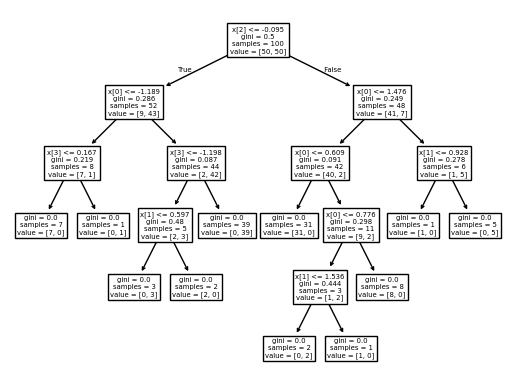

In [57]:
plot_tree(clf3)

### we will predict a random datapoint manually to see how the each Decision Tree is Predicting 


In [58]:
clf1.predict(np.array([-0.008796,	0.158807,	1.668843,	-0.031135]).reshape(1,4))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [59]:
clf2.predict(np.array([-0.008796,	0.158807,	1.668843,	-0.031135]).reshape(1,4))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [60]:
clf3.predict(np.array([-0.008796,	0.158807,	1.668843,	-0.031135]).reshape(1,4))

c:\Users\hb292\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

#### Query point Answer should be `0`